In [1]:
import kagglehub

path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

/Users/briancolclough/Documents/Coding/Applied-machine-learning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/briancolclough/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2


In [ ]:
# Use OpenCV to explore and load the dataset
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Root path that KaggleHub downloaded for us (from the previous cell)
print("Dataset root:", path)
# list all files in the root directory
print("Files in root:", os.listdir(path))

Dataset root: /Users/briancolclough/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2
Files in root: ['seg_test', 'seg_train', 'seg_pred']
Classes: ['seg_test', 'seg_train', 'seg_pred']


In [ ]:
train_dir_labels = os.path.join(path, "seg_train", "seg_train")
print('dataset labels')
print(os.listdir(train_dir_labels))

['forest', 'buildings', 'glacier', 'street', 'mountain', 'sea']


In [14]:
# Assignment constants: image size and class names
IMGSIZE = (128, 128)  # (width, height)
CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

print("IMGSIZE:", IMGSIZE)
print("Class names:", CLASS_NAMES)


IMGSIZE: (128, 128)
Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [ ]:
# Load and resize training and testing images to IMGSIZE

def load_split_images(root_path, split_name, img_size, class_names):
    X, y = [], []
    base_dir = os.path.join(root_path, split_name, split_name)
    for label_name in class_names:
        class_dir = os.path.join(base_dir, label_name)
        for f in sorted(os.listdir(class_dir)):
            if not f.lower().endswith('.jpg'):
                continue
            img_path = os.path.join(class_dir, f)
            img = cv2.imread(img_path)  # BGR
            if img is None:
                continue
            img_resized = cv2.resize(img, img_size)
            X.append(img_resized)
            y.append(class_names.index(label_name))
    X = np.stack(X, axis=0)  # shape: (N, H, W, C)
    y = np.array(y, dtype=np.int64)
    return X, y

X_tr, y_tr = load_split_images(path, 'seg_train', IMGSIZE, CLASS_NAMES)
X_ts, y_ts = load_split_images(path, 'seg_test', IMGSIZE, CLASS_NAMES)

print("Train images shape:", X_tr.shape)
print("Train labels shape:", y_tr.shape)
print("Test images shape:", X_ts.shape)
print("Test labels shape:", y_ts.shape)


Train images shape: (14034, 128, 128, 3)
Train labels shape: (14034,)
Test images shape: (3000, 128, 128, 3)
Test labels shape: (3000,)


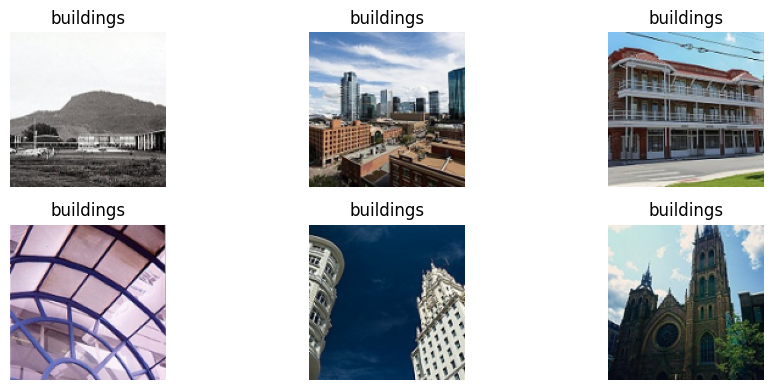

Example image shape (H, W, C): (128, 128, 3)
Number of color channels: 3


In [5]:
# Display a few example images and answer: how many color channels?

num_examples = 6
plt.figure(figsize=(10, 4))

for i in range(num_examples):
    img_bgr = X_tr[i]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(CLASS_NAMES[y_tr[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Number of color channels is the last dimension of the image shape
print("Example image shape (H, W, C):", X_tr[0].shape)
print("Number of color channels:", X_tr[0].shape[2])


In [6]:
# Convert the image sets to NumPy arrays and scale to [0, 1]

# X_tr and X_ts are already NumPy arrays of shape (N, 128, 128, 3)
print("Training array shape:", X_tr.shape)
print("Testing array shape:", X_ts.shape)

# Convert to float32 and scale pixel values to [0, 1]
X_tr_scaled = X_tr.astype('float32') / 255.0
X_ts_scaled = X_ts.astype('float32') / 255.0

print("Scaled training min/max:", X_tr_scaled.min(), X_tr_scaled.max())
print("Scaled testing min/max:", X_ts_scaled.min(), X_ts_scaled.max())


Training array shape: (14034, 128, 128, 3)
Testing array shape: (3000, 128, 128, 3)
Scaled training min/max: 0.0 1.0
Scaled testing min/max: 0.0 1.0


In [22]:
# simple neural network - prepare data for PyTorch

import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert NumPy arrays to PyTorch tensors
# Current shapes: X_tr_scaled/X_ts_scaled -> (N, 128, 128, 3)
X_train_tensor = torch.from_numpy(X_tr_scaled).permute(0, 3, 1, 2)  # (N, C, H, W)
y_train_tensor = torch.from_numpy(y_tr).long()
X_test_tensor = torch.from_numpy(X_ts_scaled).permute(0, 3, 1, 2)
y_test_tensor = torch.from_numpy(y_ts).long()

print("Train tensor shape:", X_train_tensor.shape)
print("Test tensor shape:", X_test_tensor.shape)

# Create TensorDataset and DataLoader
batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Number of training batches:", len(train_loader))
print("Number of testing batches:", len(test_loader))

Train tensor shape: torch.Size([14034, 3, 128, 128])
Test tensor shape: torch.Size([3000, 3, 128, 128])
Number of training batches: 55
Number of testing batches: 12


In [ ]:
# simple neural network model definition

import torch.nn as nn

input_dim = 128 * 128 * 3
hidden_dim = 50  
num_classes = len(CLASS_NAMES)

class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        # x has shape (batch_size, C, H, W); flatten to (batch_size, C*H*W)
        x_flat = torch.flatten(x, start_dim=1)
        return self.net(x_flat)

# add devices, I work from my laptop sometimes I need to check for both
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleMLP(input_dim, hidden_dim, num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=49152, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=50, bias=True)
    (5): ReLU()
    (6): Linear(in_features=50, out_features=6, bias=True)
  )
)


In [51]:
# simple neural network training loop

def train_model(model, optimizer, train_loader, device, num_epochs=100):
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            _, preds = outputs.max(1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - loss: {epoch_loss:.4f} - acc: {epoch_acc:.4f}")


In [ ]:
train_model(model, optimizer, train_loader, device, num_epochs=100)

Epoch 1/100 - loss: 1.2901 - acc: 0.7075
Epoch 2/100 - loss: 0.2976 - acc: 0.8980
Epoch 3/100 - loss: 0.2408 - acc: 0.9163
Epoch 4/100 - loss: 0.2237 - acc: 0.9254
Epoch 5/100 - loss: 0.2398 - acc: 0.9183
Epoch 6/100 - loss: 0.2106 - acc: 0.9281
Epoch 7/100 - loss: 0.2049 - acc: 0.9311
Epoch 8/100 - loss: 0.2459 - acc: 0.9111
Epoch 9/100 - loss: 0.2197 - acc: 0.9244
Epoch 10/100 - loss: 0.4541 - acc: 0.8448
Epoch 11/100 - loss: 0.2718 - acc: 0.9039
Epoch 12/100 - loss: 0.2404 - acc: 0.9145
Epoch 13/100 - loss: 0.2224 - acc: 0.9236
Epoch 14/100 - loss: 0.1826 - acc: 0.9398
Epoch 15/100 - loss: 0.1918 - acc: 0.9324
Epoch 16/100 - loss: 0.1872 - acc: 0.9349
Epoch 17/100 - loss: 0.2726 - acc: 0.9015
Epoch 18/100 - loss: 0.2878 - acc: 0.8948
Epoch 19/100 - loss: 0.1816 - acc: 0.9395
Epoch 20/100 - loss: 0.2009 - acc: 0.9267
Epoch 21/100 - loss: 0.2676 - acc: 0.9029
Epoch 22/100 - loss: 0.3496 - acc: 0.8776
Epoch 23/100 - loss: 0.2276 - acc: 0.9206
Epoch 24/100 - loss: 0.2115 - acc: 0.9271
E

In [30]:
# simple neural network evaluation on test set

def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        outputs = model(X_batch)
        _, preds = outputs.max(1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    test_accuracy = correct / total
    print(f"Test accuracy: {test_accuracy:.4f}")


In [31]:
evaluate_model(model, test_loader, device)

Test accuracy: 0.5563


### Train a network with dropout

In [57]:
# simple neural network model definition

import torch.nn as nn

input_dim = 128 * 128 * 3
hidden_dim = 128  
num_classes = len(CLASS_NAMES)

class SimpleMLPWithDropout(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        # x has shape (batch_size, C, H, W); flatten to (batch_size, C*H*W)
        x_flat = torch.flatten(x, start_dim=1)
        return self.net(x_flat)

# add devices, I work from my laptop sometimes I need to check for both
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_with_dropout = SimpleMLPWithDropout(input_dim, hidden_dim, num_classes).to(device)
optimizer_dropout = torch.optim.Adam(model_with_dropout.parameters(), lr=1e-3, weight_decay=1e-5)

print(model_with_dropout)


SimpleMLPWithDropout(
  (net): Sequential(
    (0): Linear(in_features=49152, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=128, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=6, bias=True)
  )
)


In [58]:
train_model(model_with_dropout, optimizer_dropout, train_loader, device, num_epochs=200)

Epoch 10/200 - loss: 1.1647 - acc: 0.5514
Epoch 20/200 - loss: 1.0947 - acc: 0.5775
Epoch 30/200 - loss: 1.0403 - acc: 0.5985
Epoch 40/200 - loss: 0.9970 - acc: 0.6144
Epoch 50/200 - loss: 0.9290 - acc: 0.6450
Epoch 60/200 - loss: 0.9127 - acc: 0.6553
Epoch 70/200 - loss: 0.8435 - acc: 0.6846
Epoch 80/200 - loss: 0.8619 - acc: 0.6779
Epoch 90/200 - loss: 0.8656 - acc: 0.6709
Epoch 100/200 - loss: 0.8393 - acc: 0.6822
Epoch 110/200 - loss: 0.8340 - acc: 0.6844
Epoch 120/200 - loss: 0.8294 - acc: 0.6849
Epoch 130/200 - loss: 0.8071 - acc: 0.6962
Epoch 140/200 - loss: 0.8521 - acc: 0.6658
Epoch 150/200 - loss: 0.8964 - acc: 0.6515
Epoch 160/200 - loss: 0.7899 - acc: 0.6932
Epoch 170/200 - loss: 0.7347 - acc: 0.7198
Epoch 180/200 - loss: 0.7107 - acc: 0.7312
Epoch 190/200 - loss: 0.7682 - acc: 0.7087
Epoch 200/200 - loss: 0.6679 - acc: 0.7448


In [59]:
evaluate_model(model_with_dropout, test_loader, device)

Test accuracy: 0.5183
